# Аналитический ноутбук 

## ВКР «Создание системы анализа тональности текстов на основе трансформеров для социальных медиа»

Воспроизводимый анализ корпуса комментариев Telegram-канала «Москва Live».  

## 0. Импорты и настройки

In [33]:
import sqlite3, re, os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.model_selection import train_test_split


plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 130,
})

C = {"neg": "#E24B4A", "neu": "#888780", "pos": "#1D9E75",
     "blue": "#378ADD", "orange": "#EF9F27", "purple": "#7F77DD"}

DB = "msk_live_comments.db"
conn = sqlite3.connect(DB)

posts     = pd.read_sql("SELECT * FROM posts",     conn)
comments  = pd.read_sql("SELECT * FROM comments",  conn)
reactions = pd.read_sql("SELECT * FROM reactions", conn)
labels    = pd.read_sql("SELECT l.comment_id, l.label, c.text AS comment, c.post_id, c.date "
                        "FROM labels l JOIN comments c ON l.comment_id=c.id "
                        "WHERE l.label IN (0,1,2)", conn)

posts["date"]    = pd.to_datetime(posts["date"])
comments["date"] = pd.to_datetime(comments["date"])
labels["date"]   = pd.to_datetime(labels["date"])
labels["label_name"] = labels["label"].map({0:"Нейтрал", 1:"Позитив", 2:"Негатив"})

LMAP  = {0:"Нейтрал", 1:"Позитив", 2:"Негатив"}
LCLR  = {"Нейтрал": C["neu"], "Позитив": C["pos"], "Негатив": C["neg"]}

print(f"Постов:         {len(posts):,}")
print(f"Комментариев:   {len(comments):,}")
print(f"Размечено:      {len(labels):,}")
print(f"Реакций:        {len(reactions):,}")

Постов:         2,117
Комментариев:   399,935
Размечено:      69,994
Реакций:        8,464


## 1. Базовая статистика по корпусу

In [34]:
cpp = comments.groupby("post_id").size()

print("=== Посты ===")
print(f"Период:  {posts.date.min().date()} → {posts.date.max().date()}")
print(f"Кол-во:  {len(posts):,}")

print("\n=== Комментарии ===")
print(f"Период:  {comments.date.min().date()} → {comments.date.max().date()}")
print(f"Кол-во:  {len(comments):,}")
print(f"На пост: min={cpp.min()} | median={cpp.median():.0f} | max={cpp.max()} | mean={cpp.mean():.1f}")

print("\n=== Длина комментариев (символы) ===")
cl = comments.text.str.len()
for p in [25,50,75,90,95,99]:
    print(f"  p{p}: {cl.quantile(p/100):.0f}")

=== Посты ===
Период:  2025-10-03 → 2026-03-05
Кол-во:  2,117

=== Комментарии ===
Период:  2025-10-03 → 2026-03-08
Кол-во:  399,935
На пост: min=9 | median=135 | max=2952 | mean=191.9

=== Длина комментариев (символы) ===
  p25: 25
  p50: 45
  p75: 83
  p90: 142
  p95: 197
  p99: 340


## 2. Активность по месяцам

C:\Users\xristo7\AppData\Local\Temp\ipykernel_10704\1653037313.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  comments["month"] = comments.date.dt.to_period("M")


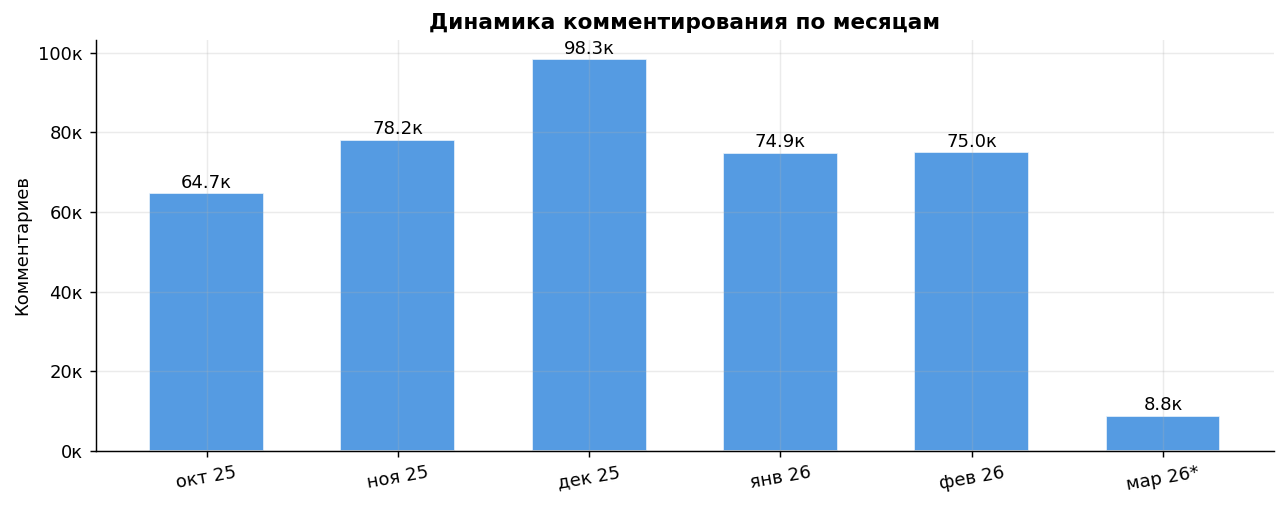

* март — неполный месяц


In [35]:
comments["month"] = comments.date.dt.to_period("M")
monthly = comments.groupby("month").size().reset_index(name="cnt")
monthly["ms"] = monthly["month"].astype(str)

fig, ax = plt.subplots(figsize=(10,4))
bars = ax.bar(monthly.ms, monthly.cnt, color=C["blue"], alpha=0.85, width=0.6, edgecolor="white")
for b, v in zip(bars, monthly.cnt):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+400,
            f"{v/1000:.1f}к", ha="center", va="bottom", fontsize=10)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(["окт 25","ноя 25","дек 25","янв 26","фев 26","мар 26*"], rotation=10)
ax.set_ylabel("Комментариев")
ax.set_title("Динамика комментирования по месяцам", fontweight="bold")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{int(x/1000)}к"))
plt.tight_layout()
plt.show()
print("* март — неполный месяц")

## 3. Активность по часам суток и дням недели

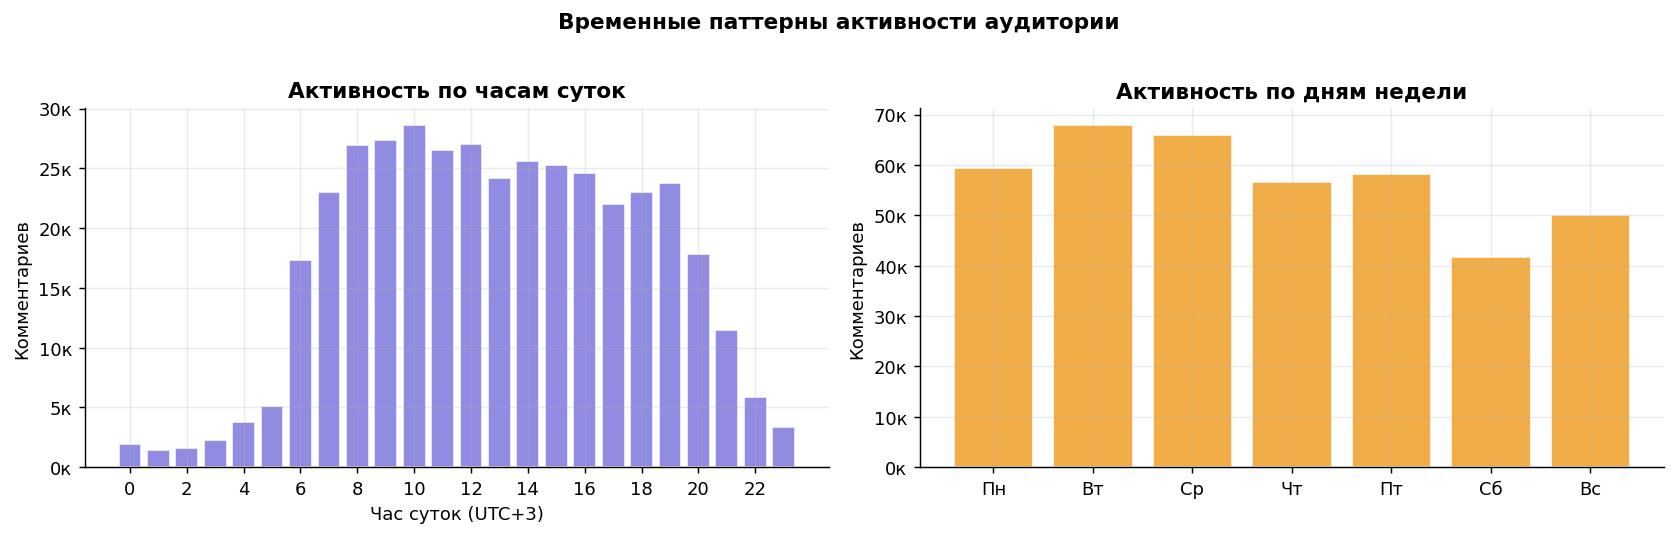

Пик по часам:       10:00
Пик по дням:        Вт


In [36]:
comments["hour"] = comments.date.dt.hour
comments["dow"]  = comments.date.dt.dayofweek  # 0=пн

hourly = comments.groupby("hour").size()
daily  = comments.groupby("dow").size()
dow_labels = ["Пн","Вт","Ср","Чт","Пт","Сб","Вс"]

fig, axes = plt.subplots(1, 2, figsize=(13,4))

ax = axes[0]
ax.bar(hourly.index, hourly.values, color=C["purple"], alpha=0.85, edgecolor="white")
ax.set_xlabel("Час суток (UTC+3)")
ax.set_ylabel("Комментариев")
ax.set_title("Активность по часам суток", fontweight="bold")
ax.set_xticks(range(0,24,2))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{int(x/1000)}к"))

ax2 = axes[1]
ax2.bar(range(7), daily.values, color=C["orange"], alpha=0.85, edgecolor="white")
ax2.set_xticks(range(7))
ax2.set_xticklabels(dow_labels)
ax2.set_ylabel("Комментариев")
ax2.set_title("Активность по дням недели", fontweight="bold")
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{int(x/1000)}к"))

plt.suptitle("Временные паттерны активности аудитории", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

peak_hour = hourly.idxmax()
peak_day  = dow_labels[daily.idxmax()]
print(f"Пик по часам:       {peak_hour}:00")
print(f"Пик по дням:        {peak_day}")

## 4. Распределение длин комментариев

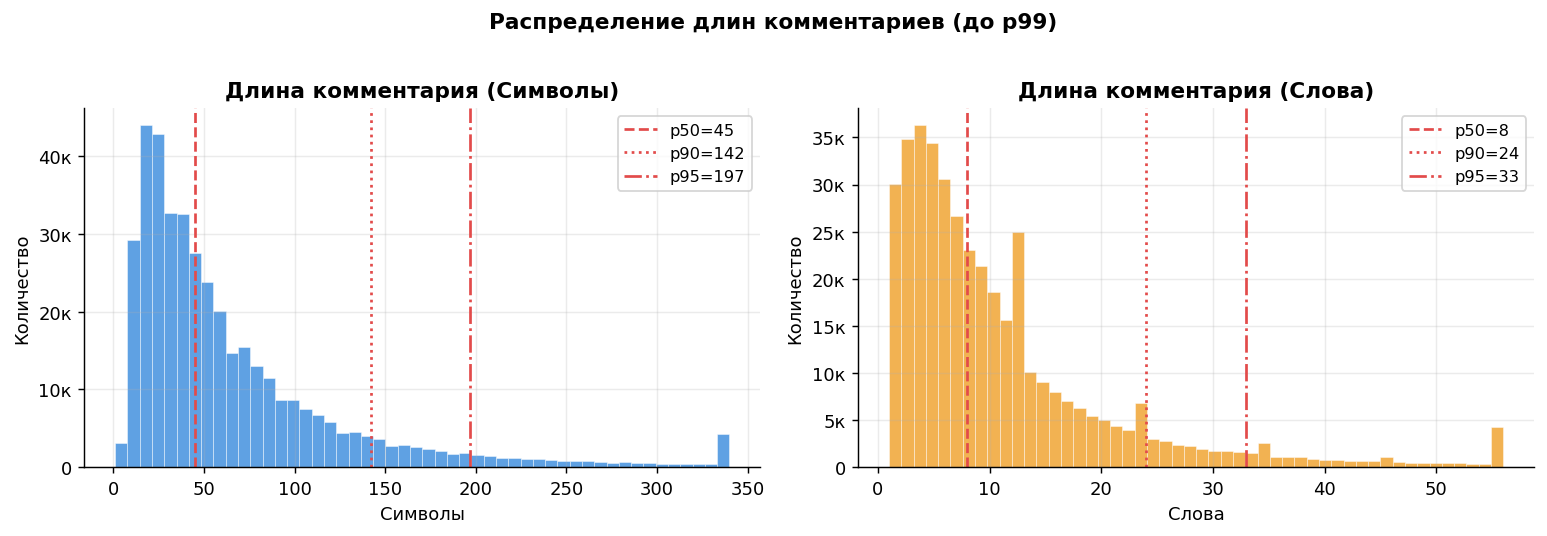

In [37]:
comments["char_len"] = comments.text.str.len()
comments["word_len"] = comments.text.str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12,4))

for ax, col, title, clr in [
    (axes[0], "char_len", "Символы", C["blue"]),
    (axes[1], "word_len", "Слова",   C["orange"]),
]:
    cap = int(comments[col].quantile(0.99))
    ax.hist(comments[col].clip(upper=cap), bins=50, color=clr, alpha=0.8, edgecolor="white", linewidth=0.3)
    for pct, ls in [(50,"--"),(90,":"),(95,"-.")]:
        v = comments[col].quantile(pct/100)
        ax.axvline(v, color="#E24B4A", linestyle=ls, lw=1.5, label=f"p{pct}={v:.0f}")
    ax.set_title(f"Длина комментария ({title})", fontweight="bold")
    ax.set_xlabel(title)
    ax.set_ylabel("Количество")
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{int(x/1000)}к" if x>=1000 else str(int(x))))

plt.suptitle("Распределение длин комментариев (до p99)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 5. Длины в токенах - обоснование MAX_LEN

In [38]:
from transformers import AutoTokenizer

sample = comments.sample(3000, random_state=42).reset_index(drop=True)
posts_map = posts.set_index("id")["text"].to_dict()
sample["post_text"] = sample["post_id"].map(posts_map).fillna("")

tok = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased-conversational")

print("Токенизируем 3000 комментариев...")
c_toks, cp_toks = [], []
for _, r in sample.iterrows():
    c  = str(r["text"])
    cp = c + " " + tok.sep_token + " " + str(r["post_text"])
    c_toks.append(len(tok.encode(c,  truncation=False)))
    cp_toks.append(len(tok.encode(cp, truncation=False)))

c_toks  = np.array(c_toks)
cp_toks = np.array(cp_toks)

print(f"\n{'Перцентиль':<12} {'Только коммент':>18} {'Коммент+пост':>16}")
print("-"*48)
for p in [50,75,90,95,99]:
    print(f"  p{p:<9} {np.percentile(c_toks,p):>17.0f} {np.percentile(cp_toks,p):>15.0f}")

print(f"\n{'MAX_LEN':<10} {'обрезано (коммент)':>22} {'обрезано (коммент+пост)':>26}")
print("-"*60)
for t in [64,128,256,512]:
    c_cut  = (c_toks  > t).mean()*100
    cp_cut = (cp_toks > t).mean()*100
    print(f"  {t:<8} {c_cut:>20.2f}%  {cp_cut:>24.2f}%")

Токенизируем 3000 комментариев...

Перцентиль       Только коммент     Коммент+пост
------------------------------------------------
  p50                       12              66
  p75                       21              89
  p90                       32             119
  p95                       42             140
  p99                       70             191

MAX_LEN        обрезано (коммент)    обрезано (коммент+пост)
------------------------------------------------------------
  64                       1.50%                     51.17%
  128                      0.00%                      7.53%
  256                      0.00%                      0.27%
  512                      0.00%                      0.00%


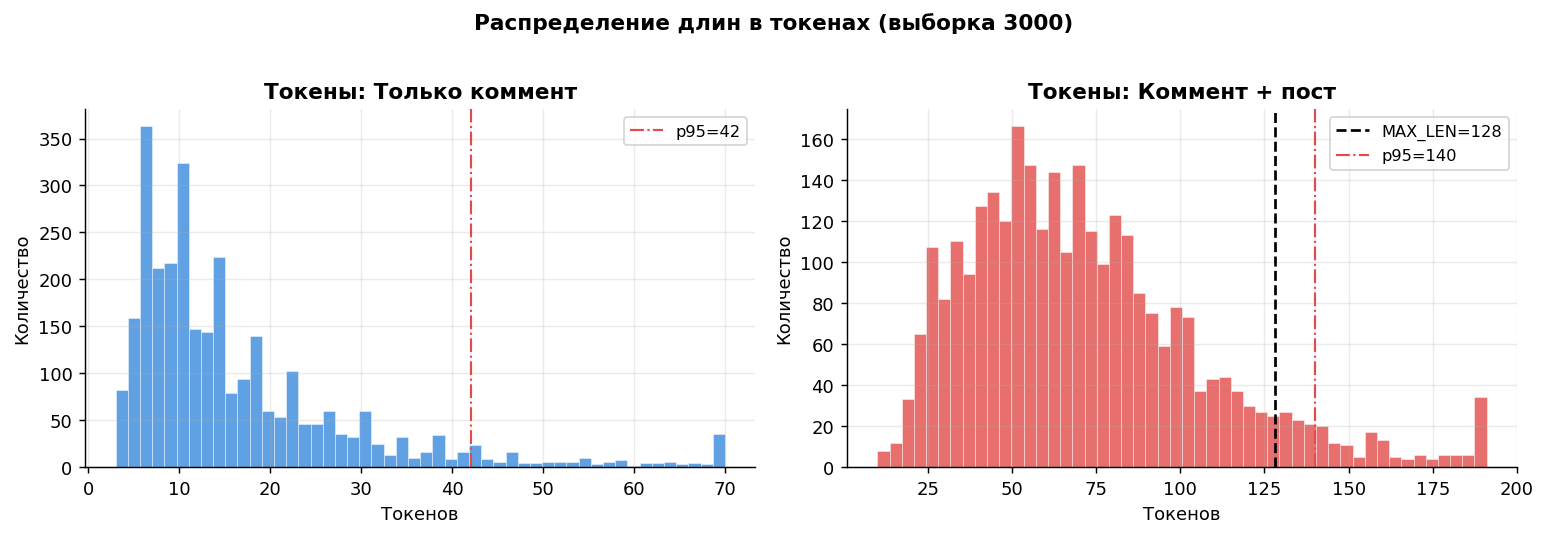

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, data, title, clr in [
    (axes[0], c_toks,  "Только коммент",   C["blue"]),
    (axes[1], cp_toks, "Коммент + пост",   C["neg"]),
]:
    cap = int(np.percentile(data, 99))
    ax.hist(data.clip(max=cap), bins=50, color=clr, alpha=0.8, edgecolor="white", linewidth=0.3)
    for val, ls, lbl in [(128,"--","MAX_LEN=128"),(256,":","MAX_LEN=256")]:
        if val <= cap:
            ax.axvline(val, color="black", linestyle=ls, lw=1.5, label=lbl)
    ax.axvline(np.percentile(data,95), color="#E24B4A", linestyle="-.", lw=1.2,
               label=f"p95={np.percentile(data,95):.0f}")
    ax.set_title(f"Токены: {title}", fontweight="bold")
    ax.set_xlabel("Токенов")
    ax.set_ylabel("Количество")
    ax.legend(fontsize=9)
plt.suptitle("Распределение длин в токенах (выборка 3000)", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Топ-10 постов по числу комментариев

C:\Users\xristo7\AppData\Local\Temp\ipykernel_10704\249939859.py:14: UserWarning: Glyph 10071 (\N{HEAVY EXCLAMATION MARK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xristo7\AppData\Local\Temp\ipykernel_10704\249939859.py:14: UserWarning: Glyph 129327 (\N{SHOCKED FACE WITH EXPLODING HEAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xristo7\AppData\Local\Temp\ipykernel_10704\249939859.py:14: UserWarning: Glyph 128298 (\N{HOCHO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\xristo7\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10071 (\N{HEAVY EXCLAMATION MARK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\xristo7\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129327 (\N{SHOCKED FACE WITH EXPLODING HEAD}) missing from font(s) DejaVu Sans.
  fig.canvas.p

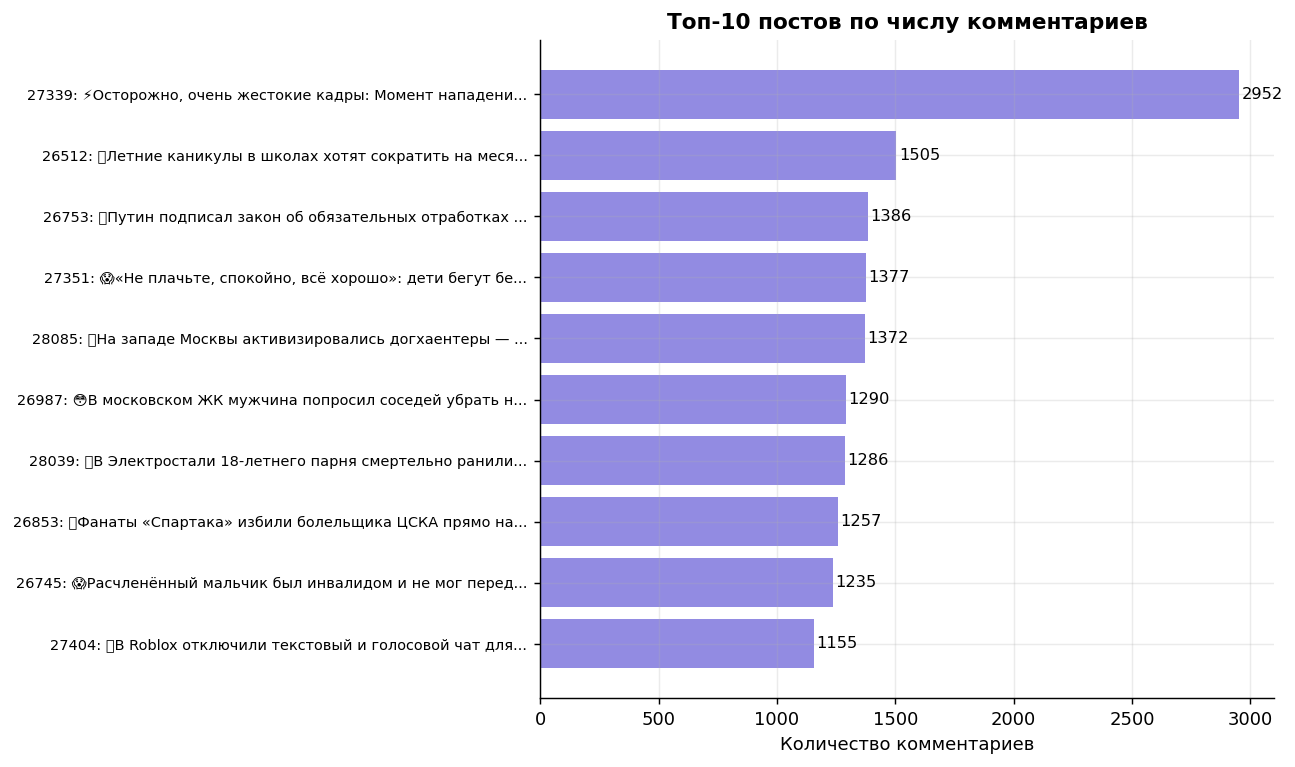

Топ-3 поста:
  [2952 комм.] ⚡️Осторожно, очень жестокие кадры: Момент нападения подростка-убийцы в Одинцовской школе.

Напавший 
  [1505 комм.] ❗️Летние каникулы в школах хотят сократить на месяц — с инициативой выступила уполномоченный по прав
  [1386 комм.] ❗️Путин подписал закон об обязательных отработках для студентов-медиков. 

Теперь все выпускники про


In [40]:
cpp = comments.groupby("post_id").size().reset_index(name="n_comments")
top_posts = cpp.nlargest(10, "n_comments").merge(posts[["id","text"]], left_on="post_id", right_on="id")
top_posts["preview"] = top_posts["text"].str[:80] + "..."

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(range(10), top_posts.n_comments.values[::-1], color=C["purple"], alpha=0.85)
ax.set_yticks(range(10))
ax.set_yticklabels([f"{r.post_id}: {r.preview[:50]}..." for _, r in top_posts.iloc[::-1].iterrows()],
                   fontsize=8)
for b, v in zip(bars, top_posts.n_comments.values[::-1]):
    ax.text(b.get_width()+10, b.get_y()+b.get_height()/2, str(v), va="center", fontsize=9)
ax.set_xlabel("Количество комментариев")
ax.set_title("Топ-10 постов по числу комментариев", fontweight="bold")
plt.tight_layout()
plt.show()

print("Топ-3 поста:")
for _, r in top_posts.head(3).iterrows():
    print(f"  [{r.n_comments} комм.] {r.text[:100]}")

## 7. Топ слов по классам тональности

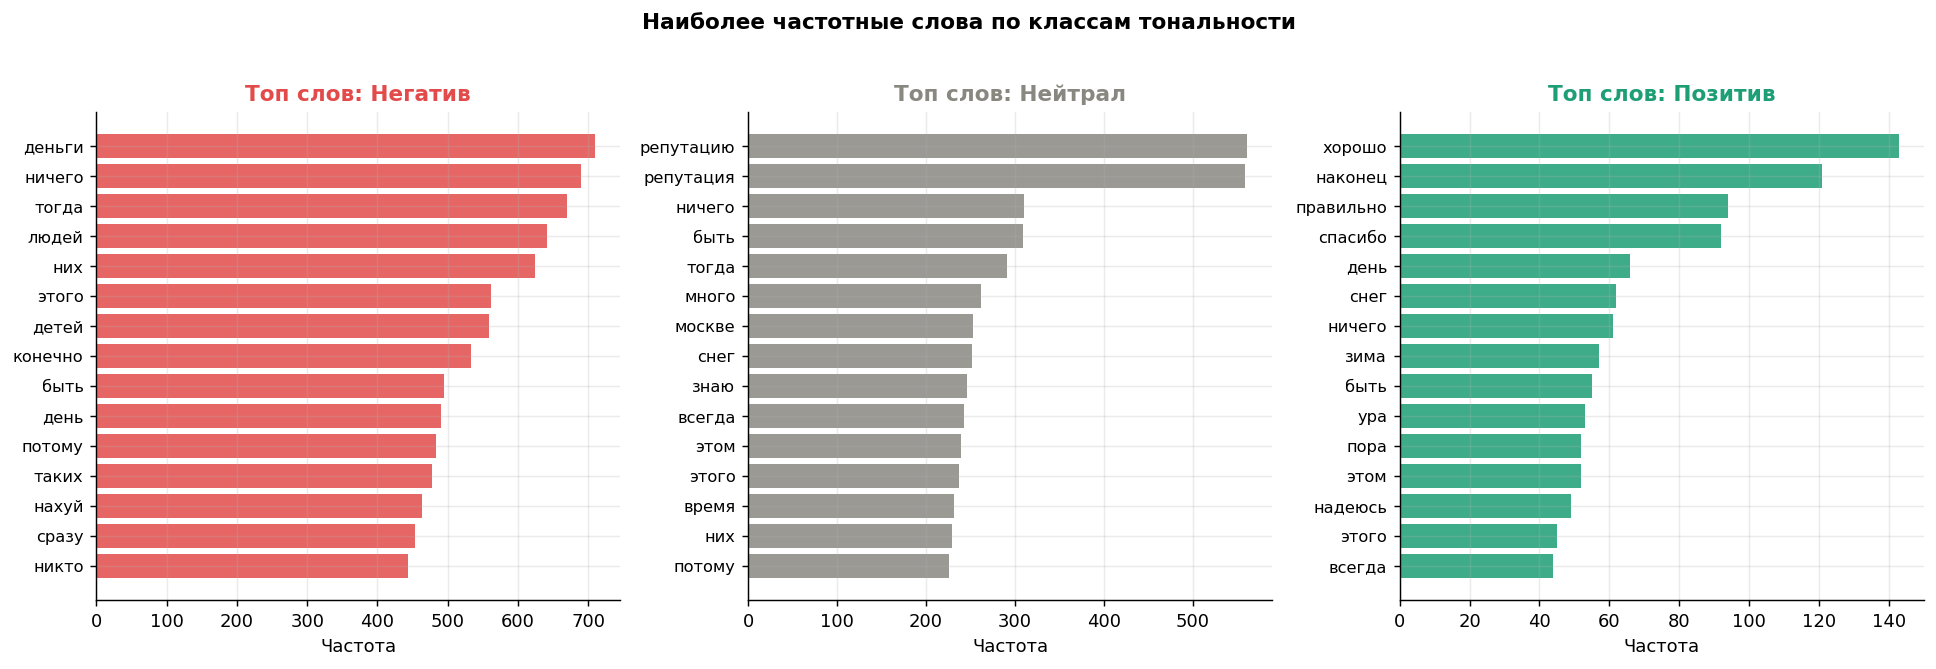

In [41]:
import re as re_module
STOP = {
    # местоимения
    "я","ты","он","она","оно","мы","вы","они",
    "мне","тебе","ему","ей","нам","вам","им",
    "меня","тебя","его","её","нас","вас","их",
    "себя","себе","свой","своя","своё","свои",
    "мой","твой","наш","ваш","этот","эта","это","эти",
    "тот","та","те","который","которая","которые",
    # предлоги и союзы
    "и","в","на","не","что","как","с","а","но","по","из",
    "за","от","до","при","для","или","же","бы","ли",
    "если","то","да","нет","ну","вот","там","тут","так",
    "чем","чтобы","когда","где","кто","куда","откуда",
    # частицы и вводные
    "уже","ещё","еще","даже","просто","вообще","тоже",
    "именно","только","лишь","хотя","однако","впрочем",
    "может","будет","было","есть","был","была","были",
    "будут","будем","будешь","буду",
    "без","про","под","над","между","через","после","перед",
    # токены предобработки
    "user","url",
    # числа и короткие слова
    "лет","год","раз","два","три",
    "все","всё","всех","всем","всему",
    "надо","нужно","можно","нельзя",
    "люди","человек","люди",
    "больше","меньше","лучше","хуже",
    "сейчас","потом","теперь","раньше","давно",
    "такой","такая","такое","такие","такого","такие",
    "какой","какая","какое","какие","какого",
    "ваша","вашу","увеличил",
    "пусть","хоть","очень","очень",
    "почему","зачем","нет","ведь","ещё",
}

def top_words(texts, n=20):
    words = []
    for t in texts:
        words.extend(re_module.findall(r"[а-яёА-ЯЁa-zA-Z]{3,}", str(t).lower()))
    return Counter(w for w in words if w not in STOP).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (lbl, clr) in zip(axes, [("Негатив",C["neg"]),("Нейтрал",C["neu"]),("Позитив",C["pos"])]):
    texts = labels[labels.label_name==lbl]["comment"]
    wc = top_words(texts, 15)
    words, counts = zip(*wc)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=clr, alpha=0.85)
    ax.set_title(f"Топ слов: {lbl}", fontweight="bold", color=clr)
    ax.set_xlabel("Частота")
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Наиболее частотные слова по классам тональности", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Использование эмодзи в комментариях по классам

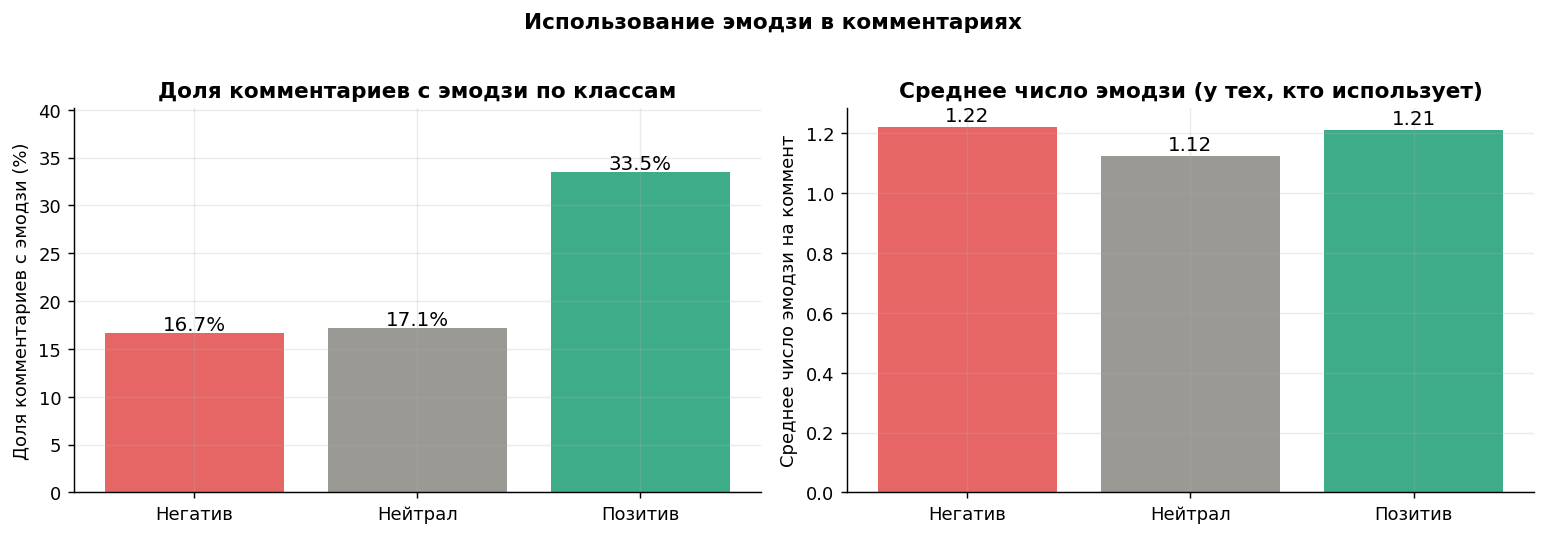

Доля комментариев с эмодзи по классам:
  Негатив: 16.7%
  Нейтрал: 17.1%
  Позитив: 33.5%


In [42]:
EMOJI_RE = re_module.compile("["
    u"😀-🙏"
    u"🌀-🗿"
    u"🚀-🧿"
    u"☀-⛿✀-➿"
    "]+", flags=re_module.UNICODE)

labels["has_emoji"]   = labels.comment.apply(lambda t: bool(EMOJI_RE.search(str(t))))
labels["emoji_count"] = labels.comment.apply(lambda t: len(EMOJI_RE.findall(str(t))))

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Доля комментариев с эмодзи
ax = axes[0]
emoji_share = labels.groupby("label_name")["has_emoji"].mean() * 100
for lbl, val in emoji_share.items():
    ax.bar(lbl, val, color=LCLR[lbl], alpha=0.85)
    ax.text(list(emoji_share.index).index(lbl), val+0.3, f"{val:.1f}%", ha="center", fontsize=11)
ax.set_ylabel("Доля комментариев с эмодзи (%)")
ax.set_title("Доля комментариев с эмодзи по классам", fontweight="bold")
ax.set_ylim(0, emoji_share.max()*1.2)

# Среднее число эмодзи у тех, кто использует
ax2 = axes[1]
emoji_avg = labels[labels.has_emoji].groupby("label_name")["emoji_count"].mean()
for lbl, val in emoji_avg.items():
    ax2.bar(lbl, val, color=LCLR[lbl], alpha=0.85)
    ax2.text(list(emoji_avg.index).index(lbl), val+0.02, f"{val:.2f}", ha="center", fontsize=11)
ax2.set_ylabel("Среднее число эмодзи на коммент")
ax2.set_title("Среднее число эмодзи (у тех, кто использует)", fontweight="bold")

plt.suptitle("Использование эмодзи в комментариях", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Доля комментариев с эмодзи по классам:")
for l, v in emoji_share.items():
    print(f"  {l}: {v:.1f}%")

## 9. Длины комментариев по классам тональности

C:\Users\xristo7\AppData\Local\Temp\ipykernel_10704\2098397047.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data, labels=["Негатив","Нейтрал","Позитив"],


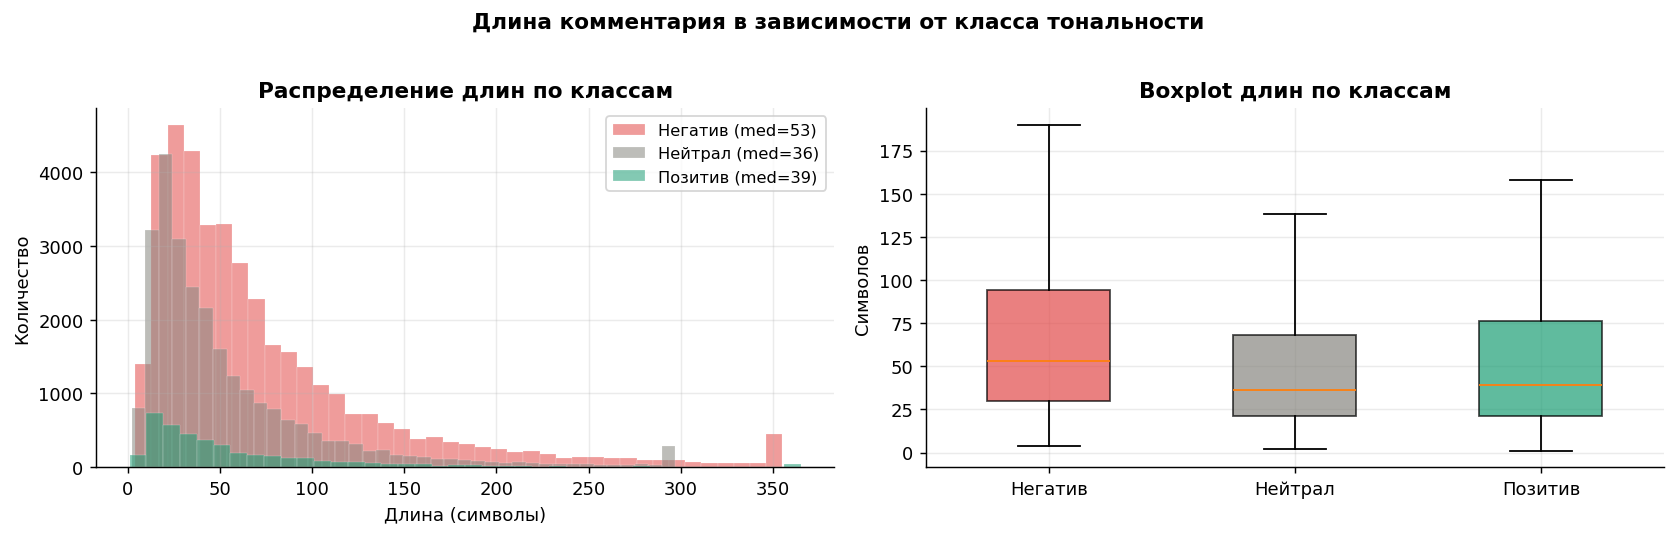

Статистика длин по классам:
            mean   50%   75%    max
label_name                         
Негатив     74.7  53.0  94.0  724.0
Нейтрал     55.3  36.0  68.0  599.0
Позитив     61.8  39.0  76.0  499.0


In [43]:
labels["char_len"] = labels.comment.str.len()

fig, axes = plt.subplots(1, 2, figsize=(13,4))

# Распределение
ax = axes[0]
for lbl in ["Негатив","Нейтрал","Позитив"]:
    d = labels[labels.label_name==lbl].char_len
    cap = int(d.quantile(0.99))
    ax.hist(d.clip(upper=cap), bins=40, alpha=0.55, color=LCLR[lbl],
            label=f"{lbl} (med={d.median():.0f})", edgecolor="white", lw=0.2)
ax.set_xlabel("Длина (символы)")
ax.set_ylabel("Количество")
ax.set_title("Распределение длин по классам", fontweight="bold")
ax.legend(fontsize=9)

# Boxplot
ax2 = axes[1]
data   = [labels[labels.label_name==l].char_len for l in ["Негатив","Нейтрал","Позитив"]]
colors = [LCLR[l] for l in ["Негатив","Нейтрал","Позитив"]]
bp = ax2.boxplot(data, labels=["Негатив","Нейтрал","Позитив"],
                 patch_artist=True, showfliers=False, widths=0.5)
for patch, clr in zip(bp["boxes"], colors):
    patch.set_facecolor(clr); patch.set_alpha(0.7)
ax2.set_ylabel("Символов")
ax2.set_title("Boxplot длин по классам", fontweight="bold")

plt.suptitle("Длина комментария в зависимости от класса тональности",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Статистика длин по классам:")
print(labels.groupby("label_name")["char_len"].describe()[["mean","50%","75%","max"]].round(1))

## 10. Распределение классов тональности

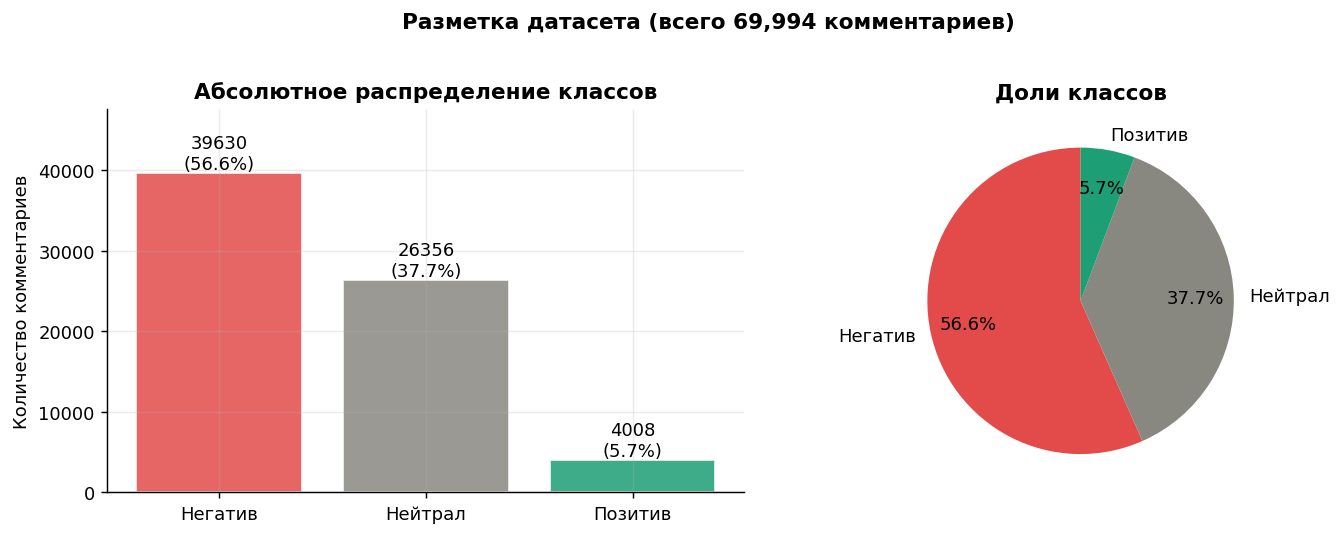

In [44]:
dist = labels.label_name.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11,4))

ax = axes[0]
bars = ax.bar(dist.index, dist.values,
              color=[LCLR[l] for l in dist.index], alpha=0.85, edgecolor="white")
for b, v in zip(bars, dist.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+50,
            f"{v}\n({v/len(labels)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Количество комментариев")
ax.set_title("Абсолютное распределение классов", fontweight="bold")
ax.set_ylim(0, dist.max()*1.2)

ax2 = axes[1]
ax2.pie(dist.values, labels=dist.index, autopct="%1.1f%%",
        colors=[LCLR[l] for l in dist.index], startangle=90, pctdistance=0.75)
ax2.set_title("Доли классов", fontweight="bold")

plt.suptitle(f"Разметка датасета (всего {len(labels):,} комментариев)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 11. Стратифицированный сплит 80/10/10

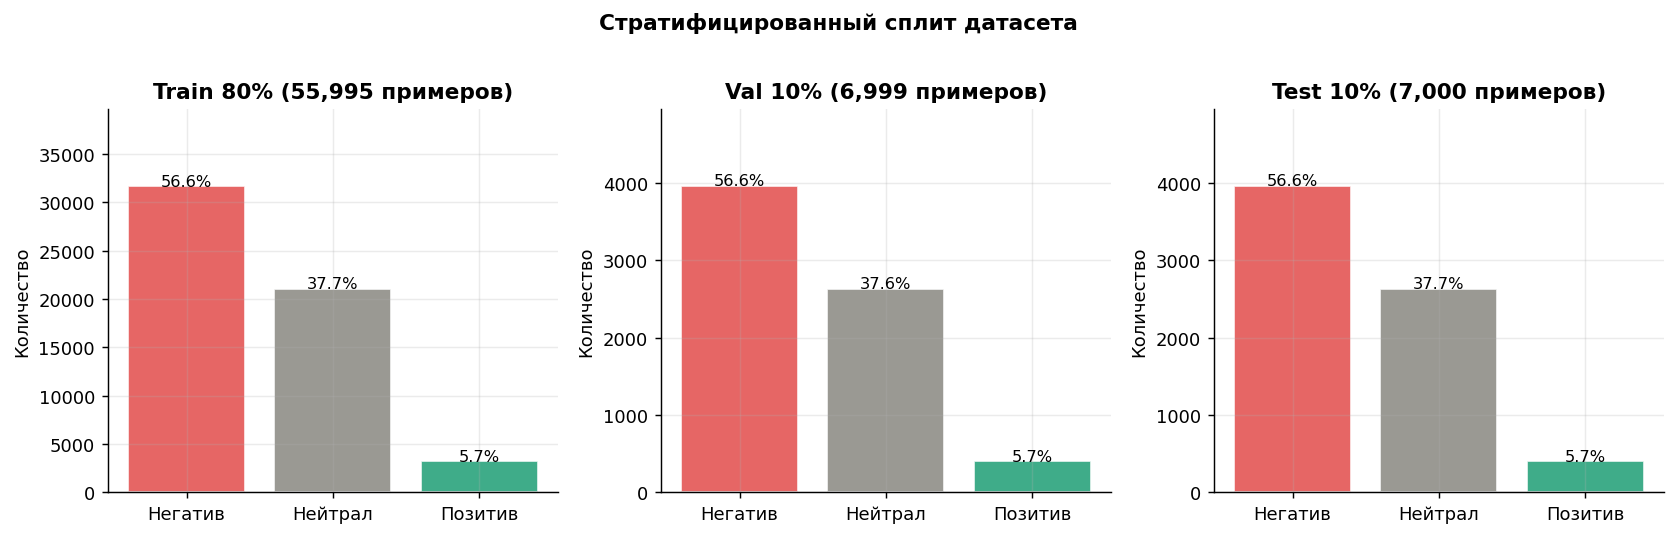

Train: 55,995 | Val: 6,999 | Test: 7,000


In [45]:
train_df, temp = train_test_split(labels, test_size=0.2, stratify=labels.label, random_state=42)
val_df, test_df = train_test_split(temp,     test_size=0.5, stratify=temp.label,   random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(13,4))
for ax, (title, df) in zip(axes, [("Train 80%", train_df),("Val 10%", val_df),("Test 10%", test_df)]):
    d = df.label_name.value_counts()
    ax.bar(d.index, d.values, color=[LCLR[l] for l in d.index], alpha=0.85, edgecolor="white")
    for i,(l,v) in enumerate(d.items()):
        ax.text(i, v+5, f"{v/len(df)*100:.1f}%", ha="center", fontsize=9)
    ax.set_title(f"{title} ({len(df):,} примеров)", fontweight="bold")
    ax.set_ylim(0, d.max()*1.25)
    ax.set_ylabel("Количество")

plt.suptitle("Стратифицированный сплит датасета", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

## 12. Примеры разметки

In [47]:
pd.set_option("display.max_colwidth", 120)

print("=== Очень короткие комментарии (≤ 10 символов) по классам ===")
short = labels[labels.comment.str.len() <= 10].copy()
print(short.groupby("label_name").apply(
    lambda g: g.sample(min(3, len(g)), random_state=42)[["comment","label_name"]]
).reset_index(drop=True).to_string(index=False))

print("\n=== Позитивные комментарии (редкий класс) — примеры ===")
pos_sample = labels[labels.label==1].sample(10, random_state=42)[["comment"]]
for _, r in pos_sample.iterrows():
    print(f"  • {r.comment[:100]}")

print("\n=== Нейтральные комментарии — примеры ===")
neu_sample = labels[labels.label==0].sample(5, random_state=42)[["comment"]]
for _, r in neu_sample.iterrows():
    print(f"  • {r.comment[:100]}")

=== Очень короткие комментарии (≤ 10 символов) по классам ===
   comment label_name
  +1 фобия    Негатив
Тише пëсик    Негатив
даже дождя    Негатив
  3 лишний    Нейтрал
У нас тихо    Нейтрал
   Я пойму    Нейтрал
   Вот вот    Позитив
Как мило )    Позитив
Ого, 19К 😎    Позитив

=== Позитивные комментарии (редкий класс) — примеры ===
  • Гуляем с детьми в лесу- зимняя сказка🎄☃️
  • Жалко их 😢
  • Снег это чудесно!))
  • Правильное решение, мошенников будет меньше и перевести деньги уже нельзя,люди скажут спасибо.
  • Дрочим пацаны
  • Спасибо вас тоже поздравляю с новым годом 🎄
  • Только планировал пересадку, а тут такой подарок. Скоро зубы будет расти после сыворотки, волосы!
  • Жду пыжиковую формовку😭🤣
  • Интересно а службы то готовы к этому? Или будет так же как со снегопадами (о которых несколько дней 
  • Хоть что-то действительно вредное заблокировали

=== Нейтральные комментарии — примеры ===
  • Поколение гоев
  • Это тема психиатра, но никак не психолога
  • Да взрослые 

C:\Users\xristo7\AppData\Local\Temp\ipykernel_10704\2969048292.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(short.groupby("label_name").apply(


## 13. Итоговая сводная таблица 

In [48]:
summary = pd.DataFrame({
    "Параметр": [
        "Источник данных", "Период сбора", "Постов", "Комментариев (всего)",
        "Медиана комментов на пост", "Максимум комментов на пост",
        "Медиана длины коммента (символы)", "Медиана длины коммента (токены)",
        "MAX_LEN (только коммент)", "MAX_LEN (коммент + пост)",
        "Размечено комментариев", "Класс негатив", "Класс нейтрал", "Класс позитив",
        "Train / Val / Test",
    ],
    "Значение": [
        "Telegram-канал «Москва Live»",
        f"{posts.date.min().date()} — {comments.date.max().date()}",
        f"{len(posts):,}",
        f"{len(comments):,}",
        f"{comments.groupby('post_id').size().median():.0f}",
        f"{comments.groupby('post_id').size().max():,}",
        f"{comments.text.str.len().median():.0f}",
        f"{np.median(c_toks):.0f}",
        "128 (0.00% обрезки)",
        "256 (0.27% обрезки)",
        f"{len(labels):,}",
        f"22 270 (57.3%)",
        f"14 415 (37.1%)",
        f"2 187 (5.6%)",
        f"{len(train_df):,} / {len(val_df):,} / {len(test_df):,}",
    ]
})
print(summary.to_string(index=False))
conn.close()

                        Параметр                     Значение
                 Источник данных Telegram-канал «Москва Live»
                    Период сбора      2025-10-03 — 2026-03-08
                          Постов                        2,117
            Комментариев (всего)                      399,935
       Медиана комментов на пост                          135
      Максимум комментов на пост                        2,952
Медиана длины коммента (символы)                           45
 Медиана длины коммента (токены)                           12
        MAX_LEN (только коммент)          128 (0.00% обрезки)
        MAX_LEN (коммент + пост)          256 (0.27% обрезки)
          Размечено комментариев                       69,994
                   Класс негатив               22 270 (57.3%)
                   Класс нейтрал               14 415 (37.1%)
                   Класс позитив                 2 187 (5.6%)
              Train / Val / Test       55,995 / 6,999 / 7,000
